In [1]:
# Import dependencies
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import CategoricalNB
from sklearn.neural_network import MLPClassifier
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split, GridSearchCV

In [2]:
# Load the Sleep and Lifestyle study data
data = pd.read_csv("./data/Sleep_health_and_lifestyle_dataset_2.csv")
data.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


Text(0.5, 1.0, 'Stress Level Distribution')

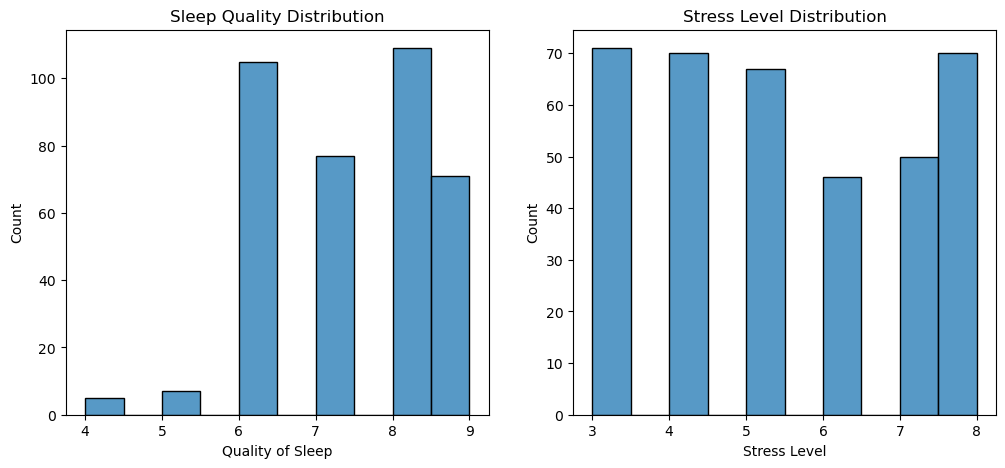

In [3]:
# Visualize the distributions of sleep quality and stress levels
fig, ax = plt.subplots(1, 2, figsize = (12, 5))
sns.histplot(data=data, x="Quality of Sleep", ax=ax[0])
ax[0].set_title("Sleep Quality Distribution")
sns.histplot(data=data, x="Stress Level", ax=ax[1])
ax[1].set_title("Stress Level Distribution")

Text(0.5, 1.0, 'Heart Rate vs. Sleep Quality')

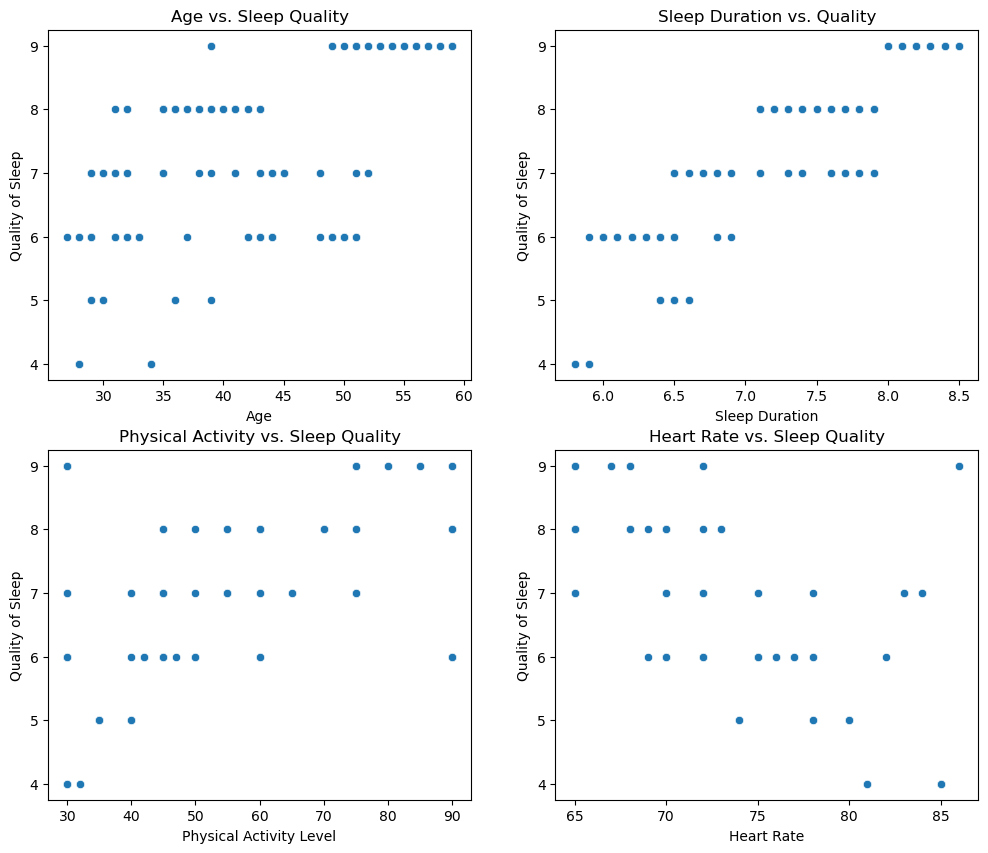

In [4]:
# Visualize realtionships between sleep quality and numerical variables
fig, ax = plt.subplots(2, 2, figsize = (12,10))
sns.scatterplot(data=data, x="Age", y="Quality of Sleep", ax=ax[0,0])
ax[0,0].set_title("Age vs. Sleep Quality")
sns.scatterplot(data=data, x="Sleep Duration", y="Quality of Sleep", ax=ax[0,1])
ax[0,1].set_title("Sleep Duration vs. Quality")
sns.scatterplot(data=data, x="Physical Activity Level", y="Quality of Sleep", ax=ax[1,0])
ax[1,0].set_title("Physical Activity vs. Sleep Quality")
sns.scatterplot(data=data, x="Heart Rate", y="Quality of Sleep", ax=ax[1,1])
ax[1,1].set_title("Heart Rate vs. Sleep Quality")

Text(0.5, 1.0, 'Heart Rate vs. Stress Level')

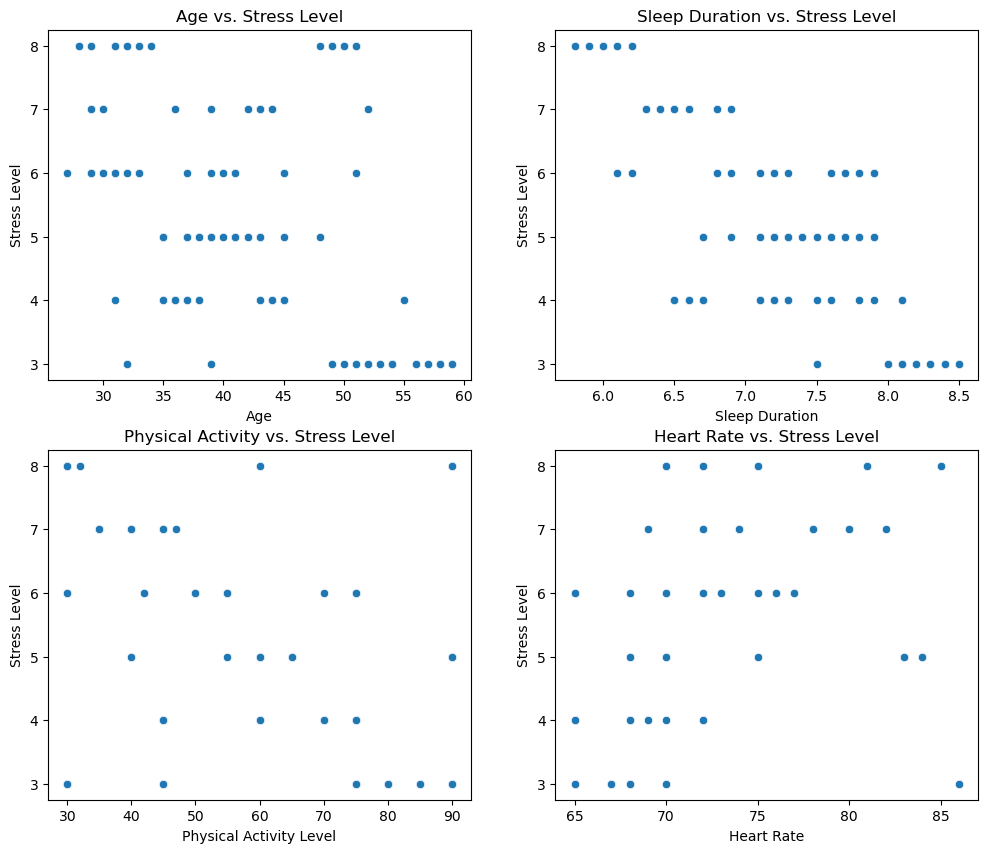

In [5]:
# Visualize realtionships between stress level and numerical variables
fig, ax = plt.subplots(2, 2, figsize = (12,10))
sns.scatterplot(data=data, x="Age", y="Stress Level", ax=ax[0,0])
ax[0,0].set_title("Age vs. Stress Level")
sns.scatterplot(data=data, x="Sleep Duration", y="Stress Level", ax=ax[0,1])
ax[0,1].set_title("Sleep Duration vs. Stress Level")
sns.scatterplot(data=data, x="Physical Activity Level", y="Stress Level", ax=ax[1,0])
ax[1,0].set_title("Physical Activity vs. Stress Level")
sns.scatterplot(data=data, x="Heart Rate", y="Stress Level", ax=ax[1,1])
ax[1,1].set_title("Heart Rate vs. Stress Level")

Text(0.5, 1.0, 'Distributions of Sleep Quality for each BMI category')

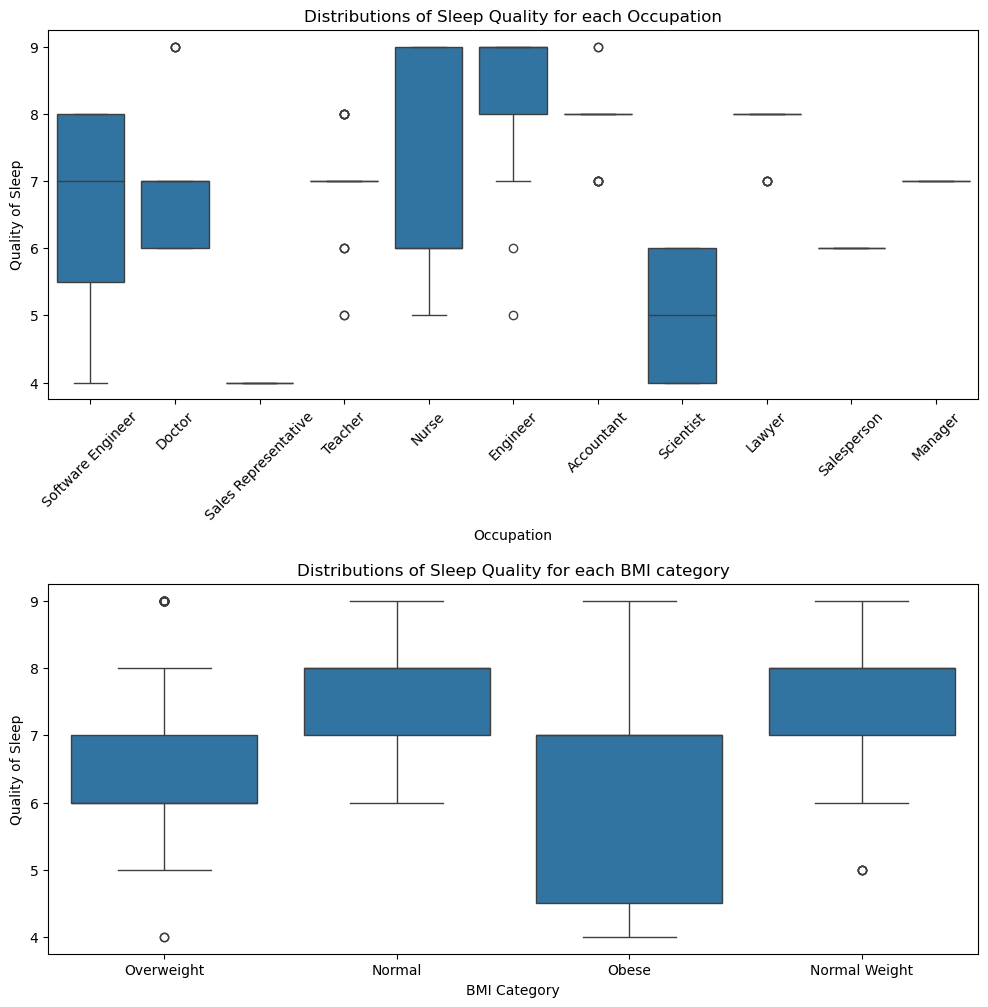

In [6]:
# Use boxplots to visualize distributions of sleep quality for each category in categorical variables
fig, ax = plt.subplots(2, 1, figsize=(12,12), gridspec_kw={'hspace': 0.5,'wspace': 0.5})
sns.boxplot(data=data, x="Occupation", y="Quality of Sleep", ax=ax[0])
ax[0].set_title("Distributions of Sleep Quality for each Occupation")
ax[0].tick_params(axis='x', labelrotation=45)
sns.boxplot(data=data, x="BMI Category", y="Quality of Sleep", ax=ax[1])
ax[1].set_title("Distributions of Sleep Quality for each BMI category")

Text(0.5, 1.0, 'Distributions of Stress Level for each BMI category')

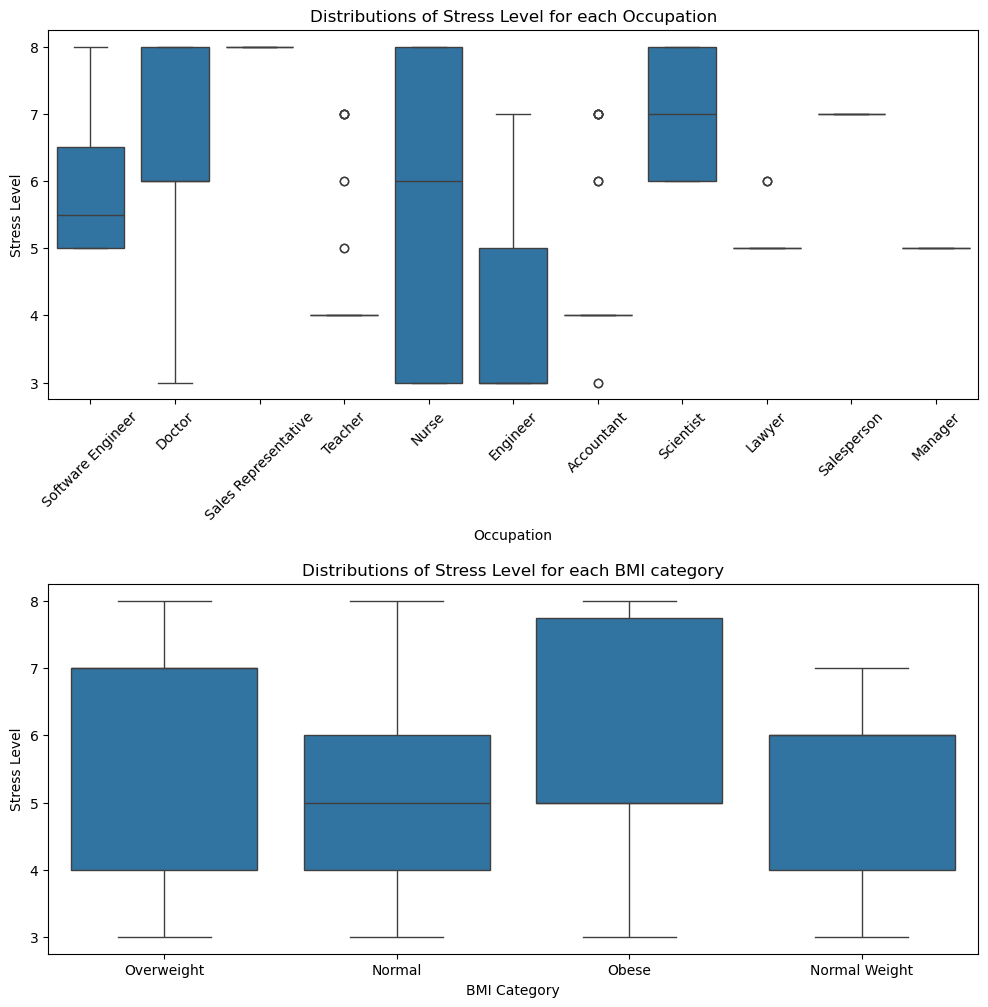

In [7]:
# Use boxplots to visualize distributions of stress level for each category in categorical variables
fig, ax = plt.subplots(2, 1, figsize=(12,12), gridspec_kw={'hspace': 0.5,'wspace': 0.5})
sns.boxplot(data=data, x="Occupation", y="Stress Level", ax=ax[0])
ax[0].set_title("Distributions of Stress Level for each Occupation")
ax[0].tick_params(axis='x', labelrotation=45)
sns.boxplot(data=data, x="BMI Category", y="Stress Level", ax=ax[1])
ax[1].set_title("Distributions of Stress Level for each BMI category")

In [8]:
# Split blood pressure into the systolic and diastolic blood pressures
data[["Systolic Blood Pressure", "Diastolic Blood Pressure"]] = data["Blood Pressure"].str.split('/', expand=True)
data[["Systolic Blood Pressure", "Diastolic Blood Pressure"]] = data[["Systolic Blood Pressure", "Diastolic Blood Pressure"]].astype(int)
data = data.drop(columns=["Blood Pressure"])

# Define different column types and separate the data into features and targets
cat_columns = ["Occupation", "BMI Category", "Sleep Disorder", "Gender"]
num_columns = ["Age", "Sleep Duration", "Physical Activity Level", "Heart Rate", "Daily Steps", "Systolic Blood Pressure", "Diastolic Blood Pressure"]
features = cat_columns + num_columns

X, sleep_quality, stress = data[features], data["Quality of Sleep"], data["Stress Level"]

In [9]:
# Convert stress to be a binary variable for binary classification (0 represents low stress, 1 represents high stress)
stress = np.where(stress > 5, 1, 0)

In [10]:
# Preform the train-test split
X_train, X_test, stress_train, stress_test, quality_train, quality_test = train_test_split(X, stress, sleep_quality, test_size = 0.1, random_state = 6)

In [11]:
# Save the combined training and testing datasets
train_combined_bin = X_train
train_combined_bin["Stress Level"] = stress_train

train_combined_multi = X_train
train_combined_multi["Quality of Sleep"] = quality_train

test_combined_bin = X_test
test_combined_bin["Stress Level"] = stress_test

test_combined_multi = X_test
test_combined_multi["Quality of Sleep"] = quality_test

train_combined_bin.to_csv("./data/training_binary.csv")
test_combined_bin.to_csv("./data/testing_binary.csv")

train_combined_multi.to_csv("./data/training_multiclass.csv")
test_combined_multi.to_csv("./data/testing_multiclass.csv")

In [12]:
# Define preprocessing for each feature
numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(drop="if_binary", handle_unknown = "ignore")
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_columns),
        ('cat', categorical_transformer, cat_columns),
    ]
)
cat_preprocessor = ColumnTransformer(
    transformers = [('cat', categorical_transformer, cat_columns)]
)
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)
X_train_cat_transformed = cat_preprocessor.fit_transform(X_train)
X_test_cat_transformed = cat_preprocessor.transform(X_test)

In [13]:
# Tune the k value of the kNN classifier using 5-fold cross validation
knn_param_grid = {
    'n_neighbors': [1, 2, 3, 4, 5, 10, 20]
}
search_knn = GridSearchCV(KNeighborsClassifier(), knn_param_grid, cv=5)
search_knn.fit(X_train_transformed, stress_train)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': [1, 2, 3, 4, 5, 10, 20]})

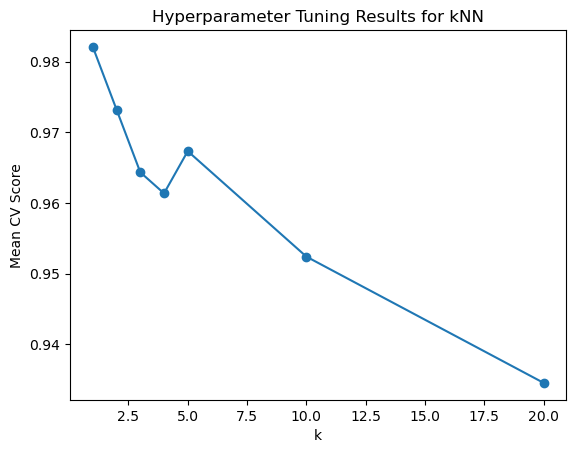

In [14]:
# Get the cross validation results and plot the mean accuracy for each parameter
results_df = pd.DataFrame(search_knn.cv_results_)
plt.figure()
plt.plot(results_df['param_n_neighbors'], results_df['mean_test_score'], marker='o')
plt.title("Hyperparameter Tuning Results for kNN")
plt.xlabel("k")
plt.ylabel("Mean CV Score")
plt.savefig("./visuals/knn_binary.png")
plt.show()

In [15]:
# Fit a kNN classifier with the best value of k
knn_classifier = KNeighborsClassifier(n_neighbors = search_knn.best_params_['n_neighbors'])
start_time = time.time()
knn_classifier.fit(X_train_transformed, stress_train)
end_time = time.time()
print(f"Training took {end_time - start_time:.4f} seconds")
print(knn_classifier.score(X_train_transformed, stress_train))

Training took 0.0003 seconds
1.0


In [16]:
# Make predictions on the test set and report the prediction accuracy of the kNN model
start_time = time.time()
stress_pred_knn = knn_classifier.predict(X_test_transformed)
end_time = time.time()
print(f"Testing took {end_time - start_time:.4f} seconds")
print(knn_classifier.score(X_test_transformed, stress_test))

Testing took 0.0025 seconds
0.9736842105263158


In [17]:
# Fit and test a decision tree classifier with a tuned max_depth
dt_param_grid = {
    'max_depth': [1, 2, 3, 5, 7, 10, None]
}
search_dt = GridSearchCV(DecisionTreeClassifier(), dt_param_grid, cv=5)
search_dt.fit(X_train_transformed, stress_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(),
             param_grid={'max_depth': [1, 2, 3, 5, 7, 10, None]})

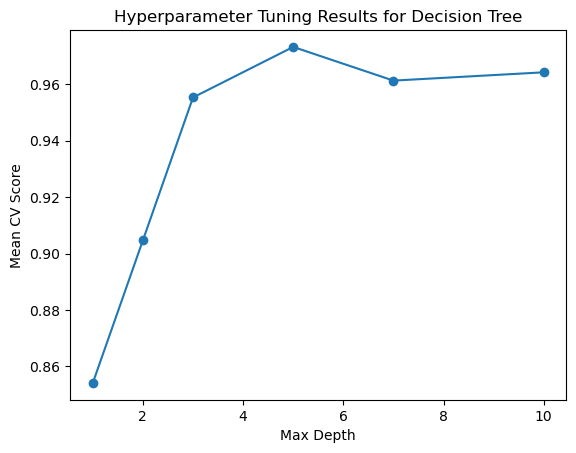

In [18]:
# Get the cross validation results and plot the mean accuracy for each parameter
results_df = pd.DataFrame(search_dt.cv_results_)
plt.figure()
plt.plot(results_df['param_max_depth'], results_df['mean_test_score'], marker='o')
plt.title("Hyperparameter Tuning Results for Decision Tree")
plt.xlabel("Max Depth")
plt.ylabel("Mean CV Score")
plt.savefig("./visuals/dt_binary.png")
plt.show()

In [19]:
dt_classifier = DecisionTreeClassifier(max_depth = search_dt.best_params_['max_depth'])
start_time = time.time()
dt_classifier.fit(X_train_transformed, stress_train)
end_time = time.time()
print(f"Training took {end_time - start_time:.4f} seconds")
print(dt_classifier.score(X_train_transformed, stress_train))

start_time = time.time()
stress_pred_dt = dt_classifier.predict(X_test_transformed)
end_time = time.time()
print(f"Testing took {end_time - start_time:.4f} seconds")
print(dt_classifier.score(X_test_transformed, stress_test))

Training took 0.0008 seconds
1.0
Testing took 0.0001 seconds
0.9473684210526315


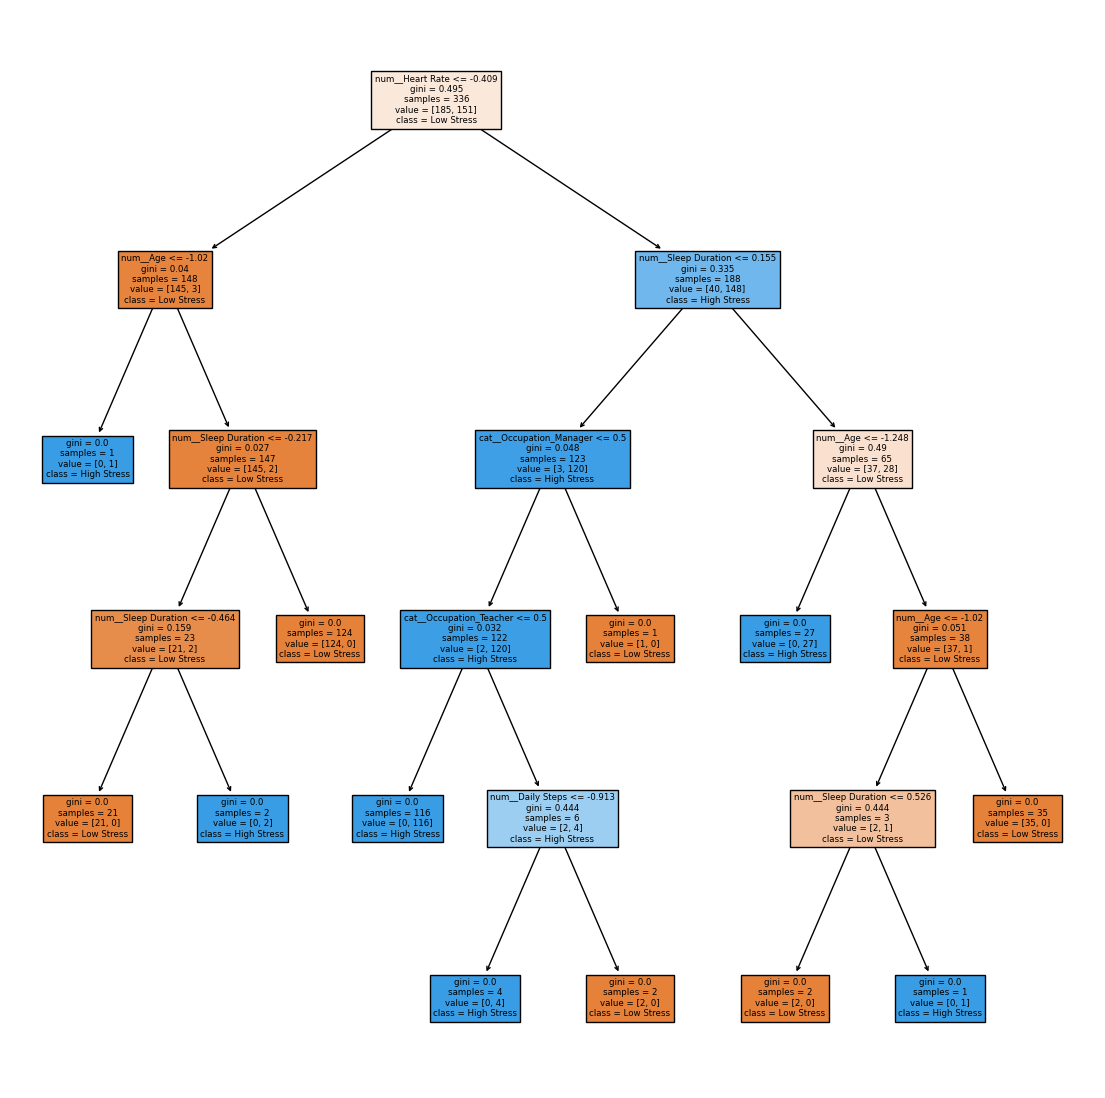

In [113]:
plt.figure(figsize=(14,14))
feature_names = preprocessor.get_feature_names_out()
plot_tree(dt_classifier, feature_names=feature_names, class_names=["Low Stress", "High Stress"], filled = True)
plt.savefig("./visuals/dt_structure_binary.png")
plt.show()

In [21]:
# Fit and test a SVM classifier with a tuned value of C and kernel chosen from linear, polynomial, and gaussian RBF using 5-fold cross validation
svm_param_grid = {
    'C': [0.1, 1, 10, 50, 100, 500, 1000],
    'kernel': ['linear', 'poly', 'rbf']
}
search_svm = GridSearchCV(SVC(), svm_param_grid, cv=5)
search_svm.fit(X_train_transformed, stress_train)

GridSearchCV(cv=5, estimator=SVC(),
             param_grid={'C': [0.1, 1, 10, 50, 100, 500, 1000],
                         'kernel': ['linear', 'poly', 'rbf']})

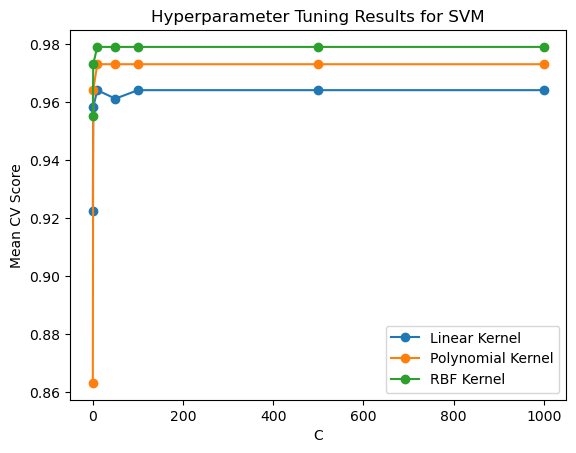

In [22]:
# Get the cross validation results and plot the mean accuracy for each parameter
results_df = pd.DataFrame(search_svm.cv_results_)
plt.figure()
plt.plot(results_df.loc[results_df['param_kernel'] == 'linear', 'param_C'], results_df.loc[results_df['param_kernel'] == 'linear', 'mean_test_score'], marker='o', label="Linear Kernel")
plt.plot(results_df.loc[results_df['param_kernel'] == 'poly', 'param_C'], results_df.loc[results_df['param_kernel'] == 'poly', 'mean_test_score'], marker='o', label="Polynomial Kernel")
plt.plot(results_df.loc[results_df['param_kernel'] == 'rbf', 'param_C'], results_df.loc[results_df['param_kernel'] == 'rbf', 'mean_test_score'], marker='o', label="RBF Kernel")
plt.title("Hyperparameter Tuning Results for SVM")
plt.xlabel("C")
plt.ylabel("Mean CV Score")
plt.legend()
plt.savefig("./visuals/svm_binary.png")
plt.show()

In [23]:
svm_classifier = SVC(C = search_svm.best_params_['C'], kernel = search_svm.best_params_['kernel'])
start_time = time.time()
svm_classifier.fit(X_train_transformed, stress_train)
end_time = time.time()
print(f"Training took {end_time - start_time:.4f} seconds")
print(svm_classifier.score(X_train_transformed, stress_train))

start_time = time.time()
stress_pred_svm = svm_classifier.predict(X_test_transformed)
end_time = time.time()
print(f"Testing took {end_time - start_time:.4f} seconds")
print(svm_classifier.score(X_test_transformed, stress_test))

Training took 0.0011 seconds
1.0
Testing took 0.0001 seconds
1.0


In [24]:
# Fit and test a random forest classifier with a tuned max depth using 5-fold cross validation
# Max depth choices are higher for random forest than for a single decision tree to take advantage of lower bias in bagging
rf_param_grid = {
    'max_depth': [3, 5, 7, 10, 13, None]
}
search_rf = GridSearchCV(RandomForestClassifier(n_estimators = 200, bootstrap = True), rf_param_grid, cv=5)
search_rf.fit(X_train_transformed, stress_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(n_estimators=200),
             param_grid={'max_depth': [3, 5, 7, 10, 13, None]})

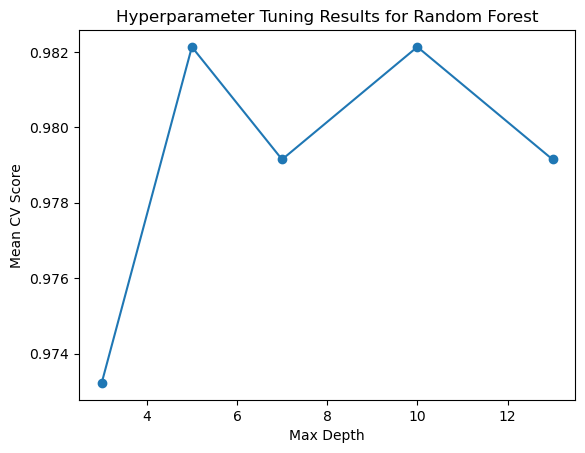

In [25]:
# Get the cross validation results and plot the mean accuracy for each parameter
results_df = pd.DataFrame(search_rf.cv_results_)
plt.figure()
plt.plot(results_df['param_max_depth'], results_df['mean_test_score'], marker='o')
plt.title("Hyperparameter Tuning Results for Random Forest")
plt.xlabel("Max Depth")
plt.ylabel("Mean CV Score")
plt.savefig("./visuals/rf_binary.png")
plt.show()

In [26]:
rf_classifier = RandomForestClassifier(max_depth = search_rf.best_params_['max_depth'], n_estimators = 200, bootstrap = True)
start_time = time.time()
rf_classifier.fit(X_train_transformed, stress_train)
end_time = time.time()
print(f"Training took {end_time - start_time:.4f} seconds")
print(rf_classifier.score(X_train_transformed, stress_train))

start_time = time.time()
stress_pred_rf = rf_classifier.predict(X_test_transformed)
end_time = time.time()
print(f"Testing took {end_time - start_time:.4f} seconds")
print(rf_classifier.score(X_test_transformed, stress_test))

Training took 0.0823 seconds
0.9910714285714286
Testing took 0.0019 seconds
0.9736842105263158


In [27]:
# Fit and test a naive Bayes classifier with a tuned additive smoothing parameter using 5-fold cross validation
nb_param_grid = {
    'alpha': [1, 2, 3]
}
search_nb = GridSearchCV(CategoricalNB(min_categories=2), nb_param_grid, cv=5)
search_nb.fit(X_train_cat_transformed.toarray(), stress_train)

GridSearchCV(cv=5, estimator=CategoricalNB(min_categories=2),
             param_grid={'alpha': [1, 2, 3]})

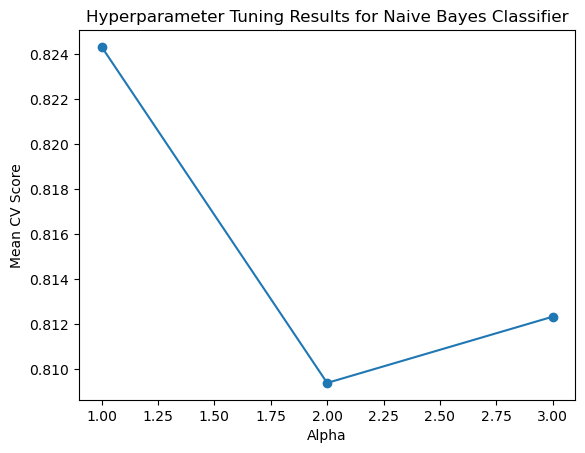

In [28]:
# Get the cross validation results and plot the mean accuracy for each parameter
results_df = pd.DataFrame(search_nb.cv_results_)
plt.figure()
plt.plot(results_df['param_alpha'], results_df['mean_test_score'], marker='o')
plt.title("Hyperparameter Tuning Results for Naive Bayes Classifier")
plt.xlabel("Alpha")
plt.ylabel("Mean CV Score")
plt.savefig("./visuals/nb_binary.png")
plt.show()

In [29]:
nb_classifier = CategoricalNB(min_categories = 2, alpha = search_nb.best_params_['alpha'])
start_time = time.time()
nb_classifier.fit(X_train_cat_transformed.toarray(), stress_train)
end_time = time.time()
print(f"Training took {end_time - start_time:.4f} seconds")
print(nb_classifier.score(X_train_cat_transformed.toarray(), stress_train))

start_time = time.time()
stress_pred_nb = nb_classifier.predict(X_test_cat_transformed.toarray())
end_time = time.time()
print(f"Testing took {end_time - start_time:.4f} seconds")
print(nb_classifier.score(X_test_cat_transformed.toarray(), stress_test))

Training took 0.0017 seconds
0.8452380952380952
Testing took 0.0001 seconds
0.868421052631579


In [30]:
# Fit and test an artificial neural network with a tuned number of hidden layer nodes, and choices of activation function and max iterations made using 5-fold cross validation
# Note: This code cell takes a long time to run
ann_param_grid = {
    'hidden_layer_sizes': [(5,), (10,), (20,), (50,), (100,), (150,)],
    'max_iter': [2000, 5000, 10000, 20000],
    'activation': ['logistic', 'tanh', 'relu']
}
search_ann = GridSearchCV(MLPClassifier(), ann_param_grid, cv=5)
search_ann.fit(X_train_transformed, stress_train)

GridSearchCV(cv=5, estimator=MLPClassifier(),
             param_grid={'activation': ['logistic', 'tanh', 'relu'],
                         'hidden_layer_sizes': [(5,), (10,), (20,), (50,),
                                                (100,), (150,)],
                         'max_iter': [2000, 5000, 10000, 20000]})

<Figure size 640x480 with 0 Axes>

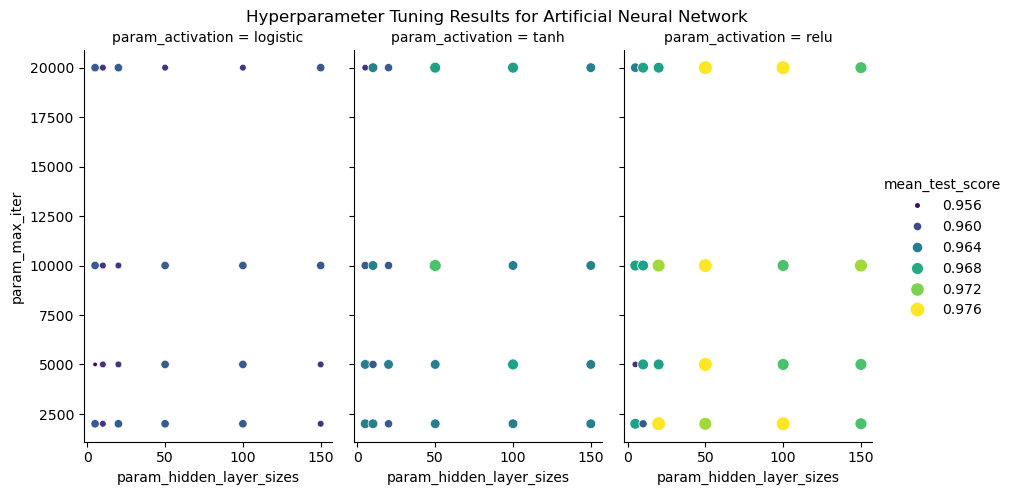

In [31]:
# Get the cross validation results and plot the mean accuracy for each parameter
results_df = pd.DataFrame(search_ann.cv_results_)
results_df['param_hidden_layer_sizes'] = results_df['param_hidden_layer_sizes'].str[0].astype(int)
plt.figure()
g = sns.relplot(data=results_df, x="param_hidden_layer_sizes", y="param_max_iter", hue="mean_test_score", col="param_activation", palette="viridis", kind="scatter", size="mean_test_score", sizes=(10,100), aspect=0.6)
g.fig.suptitle("Hyperparameter Tuning Results for Artificial Neural Network")
g.fig.subplots_adjust(top=0.9)
plt.savefig("./visuals/ann_binary.png")
plt.show()

In [32]:
ann_classifier = MLPClassifier(hidden_layer_sizes = search_ann.best_params_['hidden_layer_sizes'], max_iter = search_ann.best_params_['max_iter'], activation = search_ann.best_params_['activation'])
start_time = time.time()
ann_classifier.fit(X_train_transformed, stress_train)
end_time = time.time()
print(f"Training took {end_time - start_time:.4f} seconds")
print(ann_classifier.score(X_train_transformed, stress_train))

start_time = time.time()
stress_pred_ann = ann_classifier.predict(X_test_transformed)
end_time = time.time()
print(f"Testing took {end_time - start_time:.4f} seconds")
print(ann_classifier.score(X_test_transformed, stress_test))

Training took 0.0772 seconds
0.9940476190476191
Testing took 0.0001 seconds
0.9736842105263158


In [33]:
# Fit a kNN model for multi-class classification using a tuned k value
search_knn = GridSearchCV(KNeighborsClassifier(), knn_param_grid, cv=5)
search_knn.fit(X_train_transformed, quality_train)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': [1, 2, 3, 4, 5, 10, 20]})

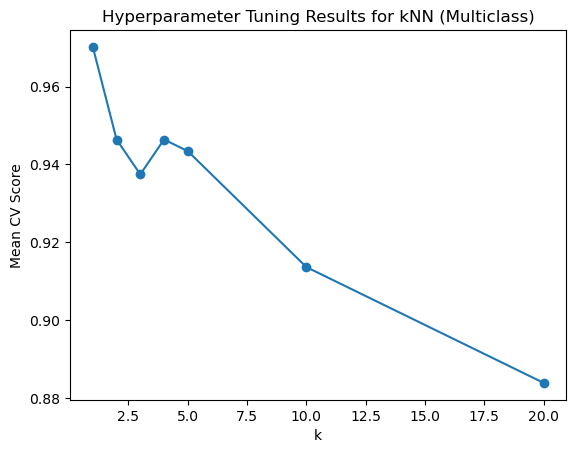

In [34]:
# Get the cross validation results and plot the mean accuracy for each parameter
results_df = pd.DataFrame(search_knn.cv_results_)
plt.figure()
plt.plot(results_df['param_n_neighbors'], results_df['mean_test_score'], marker='o')
plt.title("Hyperparameter Tuning Results for kNN (Multiclass)")
plt.xlabel("k")
plt.ylabel("Mean CV Score")
plt.savefig("./visuals/knn_multiclass.png")
plt.show()

In [35]:
knn_classifier_multi = KNeighborsClassifier(n_neighbors = search_knn.best_params_['n_neighbors'])
start_time = time.time()
knn_classifier_multi.fit(X_train_transformed, quality_train)
end_time = time.time()
print(f"Training took {end_time - start_time:.4f} seconds")
print(knn_classifier_multi.score(X_train_transformed, quality_train))

start_time = time.time()
quality_pred_knn = knn_classifier_multi.predict(X_test_transformed)
end_time = time.time()
print(f"Testing took {end_time - start_time:.4f} seconds")
print(knn_classifier_multi.score(X_test_transformed, quality_test))

Training took 0.0006 seconds
1.0
Testing took 0.0014 seconds
0.9736842105263158


In [36]:
# Fit a decision tree model for multi-class classification using a tuned max depth
search_dt = GridSearchCV(DecisionTreeClassifier(), dt_param_grid, cv=5)
search_dt.fit(X_train_transformed, quality_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(),
             param_grid={'max_depth': [1, 2, 3, 5, 7, 10, None]})

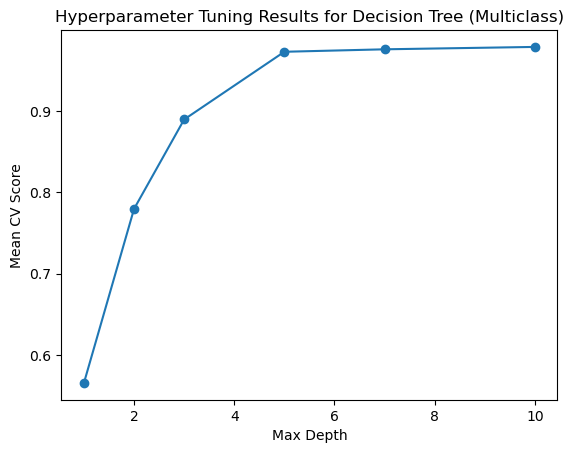

In [37]:
# Get the cross validation results and plot the mean accuracy for each parameter
results_df = pd.DataFrame(search_dt.cv_results_)
plt.figure()
plt.plot(results_df['param_max_depth'], results_df['mean_test_score'], marker='o')
plt.title("Hyperparameter Tuning Results for Decision Tree (Multiclass)")
plt.xlabel("Max Depth")
plt.ylabel("Mean CV Score")
plt.savefig("./visuals/dt_multiclass.png")
plt.show()

In [38]:
dt_classifier_multi = DecisionTreeClassifier(max_depth = search_dt.best_params_['max_depth'])
start_time = time.time()
dt_classifier_multi.fit(X_train_transformed, quality_train)
end_time = time.time()
print(f"Training took {end_time - start_time:.4f} seconds")
print(dt_classifier_multi.score(X_train_transformed, quality_train))

start_time = time.time()
quality_pred_dt = dt_classifier_multi.predict(X_test_transformed)
end_time = time.time()
print(f"Testing took {end_time - start_time:.4f} seconds")
print(dt_classifier_multi.score(X_test_transformed, quality_test))

Training took 0.0011 seconds
1.0
Testing took 0.0001 seconds
0.9473684210526315


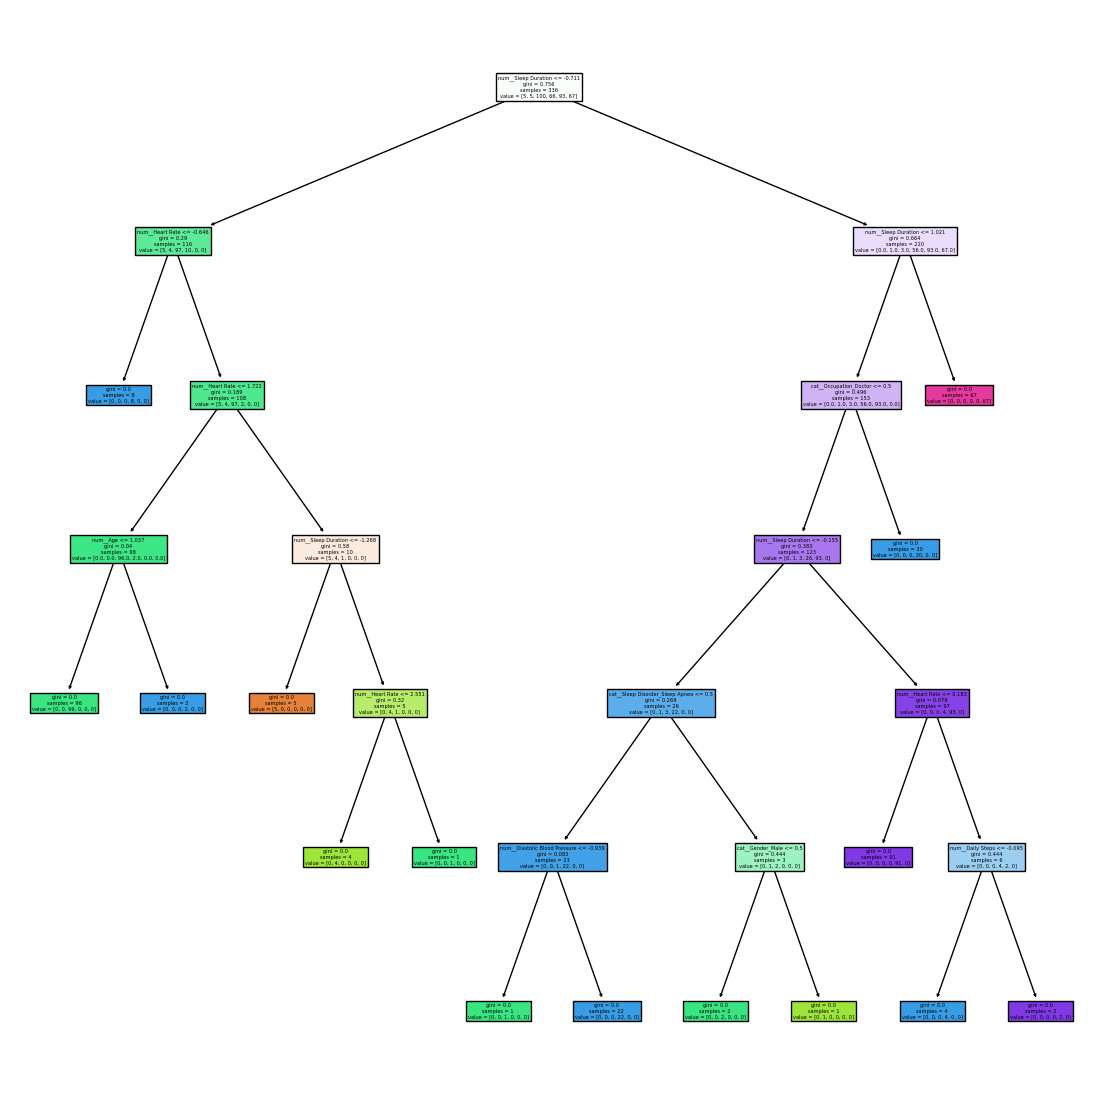

In [111]:
plt.figure(figsize=(14,14))
feature_names = preprocessor.get_feature_names_out()
plot_tree(dt_classifier_multi, feature_names=feature_names, filled = True)
plt.savefig("./visuals/dt_structure_mutliclass.png")
plt.show()

In [40]:
# Fit a random forest classifier for multi-class classification using a tuned max depth
search_rf = GridSearchCV(RandomForestClassifier(), rf_param_grid, cv=5)
search_rf.fit(X_train_transformed, quality_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(),
             param_grid={'max_depth': [3, 5, 7, 10, 13, None]})

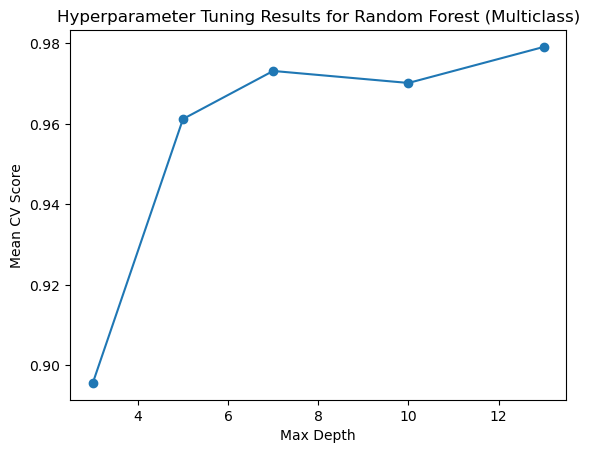

In [41]:
# Get the cross validation results and plot the mean accuracy for each parameter
results_df = pd.DataFrame(search_rf.cv_results_)
plt.figure()
plt.plot(results_df['param_max_depth'], results_df['mean_test_score'], marker='o')
plt.title("Hyperparameter Tuning Results for Random Forest (Multiclass)")
plt.xlabel("Max Depth")
plt.ylabel("Mean CV Score")
plt.savefig("./visuals/rf_multiclass.png")
plt.show()

In [42]:
rf_classifier_multi = RandomForestClassifier(max_depth = search_rf.best_params_['max_depth'])
start_time = time.time()
rf_classifier_multi.fit(X_train_transformed, quality_train)
end_time = time.time()
print(f"Training took {end_time - start_time:.4f} seconds")
print(rf_classifier_multi.score(X_train_transformed, quality_train))

start_time = time.time()
quality_pred_rf = rf_classifier_multi.predict(X_test_transformed)
end_time = time.time()
print(f"Testing took {end_time - start_time:.4f} seconds")
print(rf_classifier_multi.score(X_test_transformed, quality_test))

Training took 0.0338 seconds
1.0
Testing took 0.0010 seconds
0.9736842105263158


In [43]:
# Fit a svm classifier for multi-class classification using a tuned value of C and a kernel selected through 5-fold cross validation
search_svm = GridSearchCV(SVC(), svm_param_grid, cv=5)
search_svm.fit(X_train_transformed, quality_train)

GridSearchCV(cv=5, estimator=SVC(),
             param_grid={'C': [0.1, 1, 10, 50, 100, 500, 1000],
                         'kernel': ['linear', 'poly', 'rbf']})

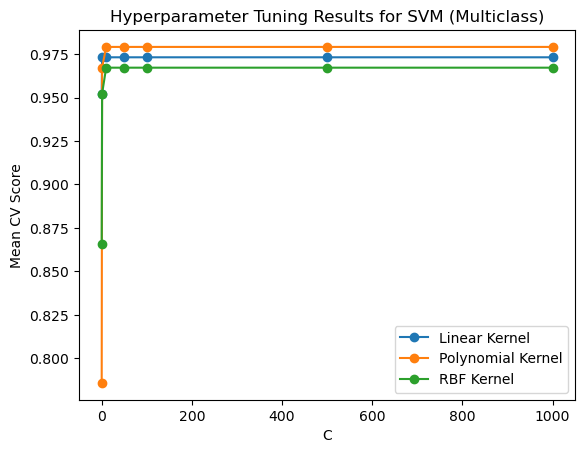

In [44]:
# Get the cross validation results and plot the mean accuracy for each parameter
results_df = pd.DataFrame(search_svm.cv_results_)
plt.figure()
plt.plot(results_df.loc[results_df['param_kernel'] == 'linear', 'param_C'], results_df.loc[results_df['param_kernel'] == 'linear', 'mean_test_score'], marker='o', label="Linear Kernel")
plt.plot(results_df.loc[results_df['param_kernel'] == 'poly', 'param_C'], results_df.loc[results_df['param_kernel'] == 'poly', 'mean_test_score'], marker='o', label="Polynomial Kernel")
plt.plot(results_df.loc[results_df['param_kernel'] == 'rbf', 'param_C'], results_df.loc[results_df['param_kernel'] == 'rbf', 'mean_test_score'], marker='o', label="RBF Kernel")
plt.title("Hyperparameter Tuning Results for SVM (Multiclass)")
plt.xlabel("C")
plt.ylabel("Mean CV Score")
plt.legend()
plt.savefig("./visuals/svm_multiclass.png")
plt.show()

In [45]:
svm_classifier_multi = SVC(C = search_svm.best_params_['C'], kernel = search_svm.best_params_['kernel'])
start_time = time.time()
svm_classifier_multi.fit(X_train_transformed, quality_train)
end_time = time.time()
print(f"Training took {end_time - start_time:.4f} seconds")
print(svm_classifier_multi.score(X_train_transformed, quality_train))

start_time = time.time()
quality_pred_svm = svm_classifier_multi.predict(X_test_transformed)
end_time = time.time()
print(f"Testing took {end_time - start_time:.4f} seconds")
print(svm_classifier_multi.score(X_test_transformed, quality_test))

Training took 0.0012 seconds
1.0
Testing took 0.0001 seconds
0.9736842105263158


In [46]:
# Fit a naive Bayes classifier for multi-class classification with a tuned alpha parameter
search_nb = GridSearchCV(CategoricalNB(min_categories=2), nb_param_grid, cv=5)
search_nb.fit(X_train_cat_transformed.toarray(), quality_train)

GridSearchCV(cv=5, estimator=CategoricalNB(min_categories=2),
             param_grid={'alpha': [1, 2, 3]})

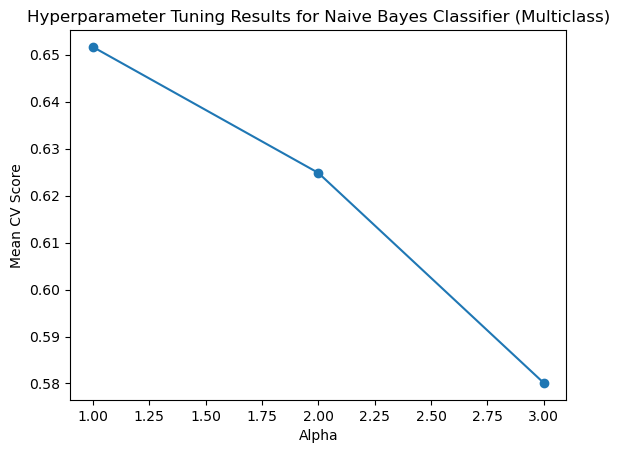

In [47]:
# Get the cross validation results and plot the mean accuracy for each parameter
results_df = pd.DataFrame(search_nb.cv_results_)
plt.figure()
plt.plot(results_df['param_alpha'], results_df['mean_test_score'], marker='o')
plt.title("Hyperparameter Tuning Results for Naive Bayes Classifier (Multiclass)")
plt.xlabel("Alpha")
plt.ylabel("Mean CV Score")
plt.savefig("./visuals/nb_multiclass.png")
plt.show()

In [48]:
nb_classifier_multi = CategoricalNB(min_categories = 2, alpha = search_nb.best_params_['alpha'])
start_time = time.time()
nb_classifier_multi.fit(X_train_cat_transformed.toarray(), quality_train)
end_time = time.time()
print(f"Training took {end_time - start_time:.4f} seconds")
print(nb_classifier_multi.score(X_train_cat_transformed.toarray(), quality_train))

start_time = time.time()
quality_pred_nb = nb_classifier_multi.predict(X_test_cat_transformed.toarray())
end_time = time.time()
print(f"Testing took {end_time - start_time:.4f} seconds")
print(nb_classifier_multi.score(X_test_cat_transformed.toarray(), quality_test))

Training took 0.0019 seconds
0.6666666666666666
Testing took 0.0001 seconds
0.7368421052631579


In [49]:
# Fit an artificial nerual network with tuned numbers of hidden layer nodes, max iterations, and an activation function selected using 5-fold cross validation
search_ann = GridSearchCV(MLPClassifier(), ann_param_grid, cv=5)
search_ann.fit(X_train_transformed, quality_train)

/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(


GridSearchCV(cv=5, estimator=MLPClassifier(),
             param_grid={'activation': ['logistic', 'tanh', 'relu'],
                         'hidden_layer_sizes': [(5,), (10,), (20,), (50,),
                                                (100,), (150,)],
                         'max_iter': [2000, 5000, 10000, 20000]})

<Figure size 640x480 with 0 Axes>

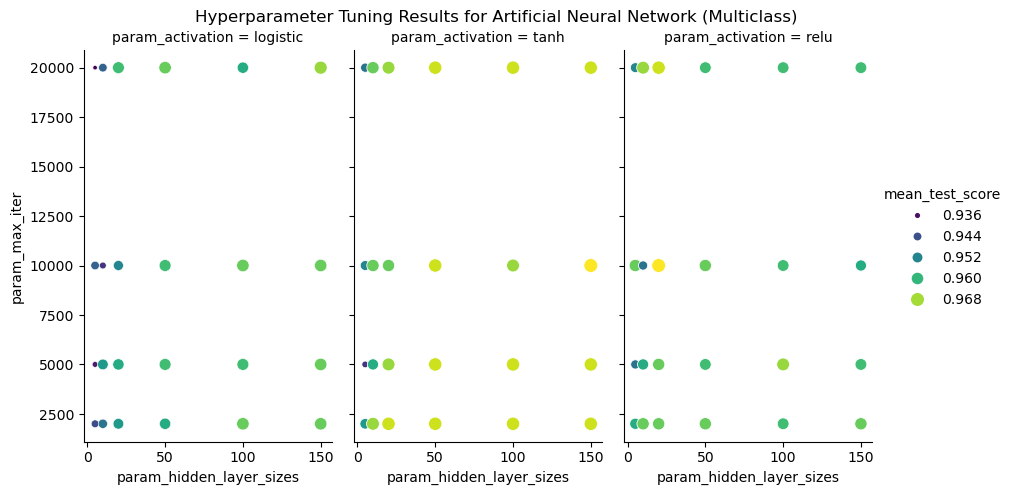

In [50]:
# Get the cross validation results and plot the mean accuracy for each parameter
results_df = pd.DataFrame(search_ann.cv_results_)
results_df['param_hidden_layer_sizes'] = results_df['param_hidden_layer_sizes'].str[0].astype(int)
plt.figure()
g = sns.relplot(data=results_df, x="param_hidden_layer_sizes", y="param_max_iter", hue="mean_test_score", col="param_activation", palette="viridis", kind="scatter", size="mean_test_score", sizes=(10,100), aspect=0.6)
g.fig.suptitle("Hyperparameter Tuning Results for Artificial Neural Network (Multiclass)")
g.fig.subplots_adjust(top=0.9)
plt.savefig("./visuals/ann_multiclass.png")
plt.show()

In [51]:
ann_classifier_multi = MLPClassifier(hidden_layer_sizes = search_ann.best_params_['hidden_layer_sizes'], max_iter = search_ann.best_params_['max_iter'], activation = search_ann.best_params_['activation'])
start_time = time.time()
ann_classifier_multi.fit(X_train_transformed, quality_train)
end_time = time.time()
print(f"Training took {end_time - start_time:.4f} seconds")
print(ann_classifier_multi.score(X_train_transformed, quality_train))

start_time = time.time()
quality_pred_ann = ann_classifier_multi.predict(X_test_transformed)
end_time = time.time()
print(f"Testing took {end_time - start_time:.4f} seconds")
print(ann_classifier_multi.score(X_test_transformed, quality_test))

Training took 0.3679 seconds
1.0
Testing took 0.0002 seconds
0.9736842105263158
